<a href="https://colab.research.google.com/github/islemtalbi/back1/blob/main/corrige_tp4_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("50_Startups.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [ ]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [ ]:
df.shape

(50, 5)

In [ ]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [ ]:
import piplite
await piplite.install('seaborn')
import seaborn as sns

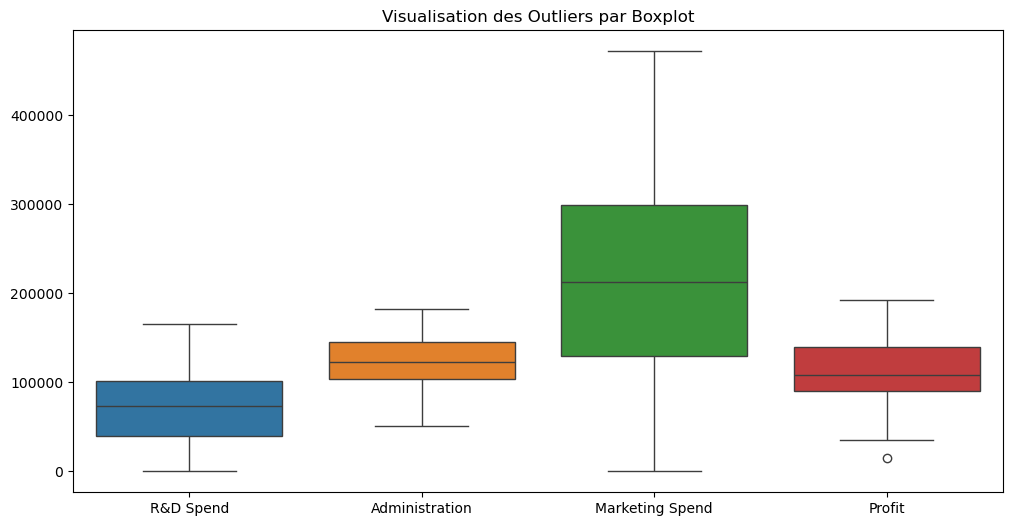

Résultats de l'analyse IQR :
Outliers détectés dans 'Profit':
    R&D Spend  Administration  Marketing Spend   Profit
49        0.0        116983.8         45173.06  14681.4
------------------------------


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement du dataset
df = pd.read_csv('50_Startups.csv')

# Sélection des colonnes numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns

# 2. Visualisation avec des Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Visualisation des Outliers par Boxplot")
plt.show()

# 3. Détection par la méthode de l'IQR (Interquartile Range)
def detect_outliers_iqr(data):
    outliers_dict = {}
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identification des lignes concernées
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_dict[col] = len(outliers)

        if not outliers.empty:
            print(f"Outliers détectés dans '{col}':")
            print(outliers)
            print("-" * 30)

    return outliers_dict

print("Résultats de l'analyse IQR :")
summary = detect_outliers_iqr(df[numeric_cols])

In [ ]:
import pandas as pd

df = pd.read_csv('50_Startups.csv')

# Calcul de l'IQR pour la colonne Profit (souvent la seule concernée ici)
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# On ne garde que les données dans les bornes
df_clean = df[(df['Profit'] >= lower_bound) & (df['Profit'] <= upper_bound)]

print(f"Taille avant : {len(df)} | Taille après : {len(df_clean)}")

Taille avant : 50 | Taille après : 49


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_label = df.copy()
df_label['State'] = le.fit_transform(df_label['State'])

print("Aperçu avec Label Encoding :")
print(df_label.head())

Aperçu avec Label Encoding :
   R&D Spend  Administration  Marketing Spend  State     Profit
0  165349.20       136897.80        471784.10      2  192261.83
1  162597.70       151377.59        443898.53      0  191792.06
2  153441.51       101145.55        407934.54      1  191050.39
3  144372.41       118671.85        383199.62      2  182901.99
4  142107.34        91391.77        366168.42      1  166187.94


In [ ]:
data = df[['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']].values
print(data)

[[165349.2  136897.8  471784.1  192261.83]
 [162597.7  151377.59 443898.53 191792.06]
 [153441.51 101145.55 407934.54 191050.39]
 [144372.41 118671.85 383199.62 182901.99]
 [142107.34  91391.77 366168.42 166187.94]
 [131876.9   99814.71 362861.36 156991.12]
 [134615.46 147198.87 127716.82 156122.51]
 [130298.13 145530.06 323876.68 155752.6 ]
 [120542.52 148718.95 311613.29 152211.77]
 [123334.88 108679.17 304981.62 149759.96]
 [101913.08 110594.11 229160.95 146121.95]
 [100671.96  91790.61 249744.55 144259.4 ]
 [ 93863.75 127320.38 249839.44 141585.52]
 [ 91992.39 135495.07 252664.93 134307.35]
 [119943.24 156547.42 256512.92 132602.65]
 [114523.61 122616.84 261776.23 129917.04]
 [ 78013.11 121597.55 264346.06 126992.93]
 [ 94657.16 145077.58 282574.31 125370.37]
 [ 91749.16 114175.79 294919.57 124266.9 ]
 [ 86419.7  153514.11      0.   122776.86]
 [ 76253.86 113867.3  298664.47 118474.03]
 [ 78389.47 153773.43 299737.29 111313.02]
 [ 73994.56 122782.75 303319.26 110352.25]
 [ 67532.53

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Charger le fichier CSV
df = pd.read_csv('50_Startups.csv')

# 2. Encoder la colonne 'State' (one-hot encoding)
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# 3. Séparer les caractéristiques (X) et la cible (y)
X = df_encoded.drop('Profit', axis=1).values   # toutes les colonnes sauf Profit
y = df_encoded['Profit'].values                 # la colonne Profit

# 4. Diviser en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Vérifier les dimensions
print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (40, 5)
Dimensions de X_test  : (10, 5)
Dimensions de y_train : (40,)
Dimensions de y_test  : (10,)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Charger et préparer les données
df = pd.read_csv('50_Startups.csv')
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# 2. Séparer les caractéristiques (X) et la cible (y)
X = df_encoded.drop('Profit', axis=1).values   # toutes les colonnes sauf Profit
y = df_encoded['Profit'].values

# 3. Diviser en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # calcule moyenne et écart-type sur train, puis transforme
X_test_scaled = scaler.transform(X_test)         # utilise les mêmes paramètres pour transformer test

# 5. Vérification rapide
print("Moyenne de X_train avant standardisation :", X_train.mean(axis=0))
print("Moyenne de X_train après standardisation :", X_train_scaled.mean(axis=0).round(6))
print("Écart-type de X_train après standardisation :", X_train_scaled.std(axis=0).round(6))
print("\nDimensions après standardisation :")
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

Moyenne de X_train avant standardisation : [77687.8455 121142.92274999994 235747.08099999995 0.35 0.325]
Moyenne de X_train après standardisation : [0. 0. 0. 0. 0.]
Écart-type de X_train après standardisation : [1. 1. 1. 1. 1.]

Dimensions après standardisation :
X_train_scaled : (40, 5)
X_test_scaled  : (10, 5)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# 4. Créer et entraîner le modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Prédire sur l'ensemble de test
y_pred = model.predict(X_test)

# 6. Évaluer les performances
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RÉGRESSION LINÉAIRE SIMPLE (R&D Spend) ===")
print(f"Coefficient : {model.coef_[0]:.2f}")
print(f"Intercept   : {model.intercept_:.2f}")
print(f"RMSE        : {rmse:.2f}")
print(f"R²          : {r2:.4f}")

=== RÉGRESSION LINÉAIRE SIMPLE (R&D Spend) ===
Coefficient : 0.81
Intercept   : 54028.04
RMSE        : 9055.96
R²          : 0.8987


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
# 6. Entraîner un modèle Ridge avec validation croisée pour choisir alpha
#    (RidgeCV essaie automatiquement plusieurs valeurs d'alpha)
alphas = np.logspace(-3, 3, 50)  # 50 valeurs de 0.001 à 1000
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# 7. Afficher le meilleur alpha trouvé
print(f"Meilleur alpha sélectionné : {ridge_cv.alpha_:.4f}")

# 8. Prédire sur l'ensemble de test
y_pred = ridge_cv.predict(X_test_scaled)

# 9. Évaluer les performances
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE sur le test : {rmse:.2f}")
print(f"R² sur le test   : {r2:.4f}")

Meilleur alpha sélectionné : 0.1600
RMSE sur le test : 9070.35
R² sur le test   : 0.8984


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# 1. Charger les données
df = pd.read_csv('50_Startups.csv')

# 2. Encoder la colonne 'State' (one-hot)
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# 3. Séparer X et y (garder les DataFrames pour les noms de colonnes)
X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

# 4. Diviser en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Backward elimination sur l'ensemble d'entraînement
def backward_elimination(X, y, sl=0.05):
    """
    Sélectionne les variables par backward elimination basée sur la p-value.
    X : DataFrame pandas (features)
    y : Series pandas (cible)
    sl : seuil de significativité (p-value)
    Retourne les noms des colonnes sélectionnées.
    """
    # Forcer le type float pour éviter l'erreur "object"
    X = X.astype(float)
    y = y.astype(float)

    X_with_const = sm.add_constant(X)  # ajouter la constante
    cols = list(X_with_const.columns)
    while True:
        model = sm.OLS(y, X_with_const[cols]).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p > sl:
            # Supprimer la variable avec la plus grande p-value
            removed = p_values.idxmax()
            cols.remove(removed)
        else:
            break
    # Enlever la constante de la liste finale
    cols.remove('const')
    return cols

selected_features = backward_elimination(X_train, y_train, sl=0.05)
print("Variables sélectionnées :", selected_features)

# 6. Entraîner un modèle linéaire avec les variables retenues
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

lr = LinearRegression()
lr.fit(X_train_sel, y_train)
y_pred = lr.predict(X_test_sel)

# 7. Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n=== ÉVALUATION SUR TEST ===")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# (Optionnel) Résumé statistique du modèle final avec statsmodels
X_train_sel_const = sm.add_constant(X_train_sel.astype(float))
model_final = sm.OLS(y_train.astype(float), X_train_sel_const).fit()
print(model_final.summary())

Variables sélectionnées : ['R&D Spend']

=== ÉVALUATION SUR TEST ===
RMSE : 7714.33
R²   : 0.9265
                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     676.1
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           8.22e-26
Time:                        10:12:52   Log-Likelihood:                -423.42
No. Observations:                  40   AIC:                             850.8
Df Residuals:                      38   BIC:                             854.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm


# Dictionnaire pour stocker les résultats
results = {}



# -------------------------------------------------------------------
# 7. Régression linéaire simple (avec R&D Spend uniquement)
X_simple = df[['R&D Spend']].values
y_simple = df['Profit'].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train_s)
y_pred_simple = lr_simple.predict(X_test_s)
results['Régression simple (R&D)'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_s, y_pred_simple)),
    'R2'  : r2_score(y_test_s, y_pred_simple)
}

# -------------------------------------------------------------------
# 8. Régression linéaire multiple (toutes les variables encodées)
lr_mult = LinearRegression()
lr_mult.fit(X_train_scaled, y_train)   # utilisation des données standardisées pour comparer coefficients
y_pred_mult = lr_mult.predict(X_test_scaled)
results['Régression multiple'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_mult)),
    'R2'  : r2_score(y_test, y_pred_mult)
}

# -------------------------------------------------------------------
# 9. Ridge (avec sélection automatique de alpha)
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
results['Ridge (CV)'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'R2'  : r2_score(y_test, y_pred_ridge),
    'Best alpha': ridge_cv.alpha_
}

# -------------------------------------------------------------------
# 10. Backward Elimination (avec statsmodels)
def backward_elimination(X, y, sl=0.05):
    X = X.astype(float)
    y = y.astype(float)
    X_with_const = sm.add_constant(X)
    cols = list(X_with_const.columns)
    while True:
        model = sm.OLS(y, X_with_const[cols]).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p > sl:
            removed = p_values.idxmax()
            cols.remove(removed)
        else:
            break
    cols.remove('const')
    return cols

selected = backward_elimination(X_train, y_train)
print("Variables retenues par Backward Elimination :", selected)

X_train_be = X_train[selected]
X_test_be = X_test[selected]
lr_be = LinearRegression()
lr_be.fit(X_train_be, y_train)
y_pred_be = lr_be.predict(X_test_be)
results['Backward Elimination'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_be)),
    'R2'  : r2_score(y_test, y_pred_be)
}

# -------------------------------------------------------------------
# 11. Affichage des résultats
print("\n" + "="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)
for model, metrics in results.items():
    print(f"\n{model}")
    print(f"  RMSE : {metrics['RMSE']:.2f}")
    print(f"  R²   : {metrics['R2']:.4f}")
    if 'Best k' in metrics:
        print(f"  Meilleur k : {metrics['Best k']}")
    if 'Best alpha' in metrics:
        print(f"  Meilleur alpha : {metrics['Best alpha']:.4f}")

Variables retenues par Backward Elimination : ['R&D Spend']

COMPARAISON DES MODÈLES

Régression simple (R&D)
  RMSE : 7714.33
  R²   : 0.9265

Régression multiple
  RMSE : 9055.96
  R²   : 0.8987

Ridge (CV)
  RMSE : 9070.35
  R²   : 0.8984
  Meilleur alpha : 0.1600

Backward Elimination
  RMSE : 7714.33
  R²   : 0.9265


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ====================== 1. CHARGEMENT & PRÉPARATION ======================
df = pd.read_csv('50_Startups.csv')
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# Toutes les variables (pour ridge et backward elimination)
X_all = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

# Division train/test (même seed pour tous les modèles)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ====================== 2. RÉGRESSION LINÉAIRE SIMPLE (R&D Spend) ======================
print("="*60)
print("RÉGRESSION LINÉAIRE SIMPLE (R&D Spend)")
print("="*60)

# Utiliser seulement la colonne R&D Spend
X_simple = df[['R&D Spend']].values
y_simple = df['Profit'].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train_s)
y_pred_simple = lr_simple.predict(X_test_s)

rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
r2_simple = r2_score(y_test_s, y_pred_simple)

print(f"RMSE (test) : {rmse_simple:.2f}")
print(f"R²   (test) : {r2_simple:.4f}")
print(f"Coefficient : {lr_simple.coef_[0]:.2f}")
print(f"Intercept   : {lr_simple.intercept_:.2f}")

# Résumé statsmodels (sur train)
X_train_s_const = sm.add_constant(X_train_s.astype(float))
model_simple_sm = sm.OLS(y_train_s.astype(float), X_train_s_const).fit()
print("\n--- Résumé statsmodels (entraînement) ---")
print(model_simple_sm.summary().tables[1])  # tableau des coefficients
print("\n")

# ====================== 3. RIDGE RÉGRESSION (toutes variables encodées) ======================
print("="*60)
print("RIDGE RÉGRESSION")
print("="*60)

# Standardisation indispensable pour Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Recherche du meilleur alpha par validation croisée
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Meilleur alpha : {ridge_cv.alpha_:.4f}")
print(f"RMSE (test)    : {rmse_ridge:.2f}")
print(f"R²   (test)    : {r2_ridge:.4f}")
print("Coefficients (avec scaling) :", ridge_cv.coef_)
print("Intercept (avec scaling)    :", ridge_cv.intercept_)
print("\n")

# ====================== 4. BACKWARD ELIMINATION ======================
print("="*60)
print("BACKWARD ELIMINATION")
print("="*60)

def backward_elimination(X, y, sl=0.05):
    """Retourne la liste des colonnes sélectionnées par backward elimination (p-value)."""
    X = X.astype(float)
    y = y.astype(float)
    X_with_const = sm.add_constant(X)
    cols = list(X_with_const.columns)
    while True:
        model = sm.OLS(y, X_with_const[cols]).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p > sl:
            removed = p_values.idxmax()
            cols.remove(removed)
        else:
            break
    cols.remove('const')
    return cols

selected = backward_elimination(X_train, y_train)
print("Variables sélectionnées :", selected)

# Entraîner un modèle linéaire avec ces variables
X_train_be = X_train[selected]
X_test_be = X_test[selected]

lr_be = LinearRegression()
lr_be.fit(X_train_be, y_train)
y_pred_be = lr_be.predict(X_test_be)

rmse_be = np.sqrt(mean_squared_error(y_test, y_pred_be))
r2_be = r2_score(y_test, y_pred_be)

print(f"RMSE (test) : {rmse_be:.2f}")
print(f"R²   (test) : {r2_be:.4f}")

# Résumé statsmodels du modèle final (sur train)
X_train_be_const = sm.add_constant(X_train_be.astype(float))
model_be_sm = sm.OLS(y_train.astype(float), X_train_be_const).fit()
print("\n--- Résumé statsmodels (modèle final, entraînement) ---")
print(model_be_sm.summary().tables[1])
print("\n")

# ====================== 5. TABLEAU RÉCAPITULATIF ======================
print("="*60)
print("RÉCAPITULATIF DES PERFORMANCES (SUR TEST)")
print("="*60)
print(f"\nRégression simple (R&D Spend)")
print(f"  RMSE : {rmse_simple:.2f}")
print(f"  R²   : {r2_simple:.4f}")
print(f"\nRidge (CV)")
print(f"  RMSE : {rmse_ridge:.2f}")
print(f"  R²   : {r2_ridge:.4f}")
print(f"  Meilleur alpha : {ridge_cv.alpha_:.4f}")
print(f"\nBackward Elimination")
print(f"  RMSE : {rmse_be:.2f}")
print(f"  R²   : {r2_be:.4f}")
print(f"  Variables sélectionnées : {selected}")

RÉGRESSION LINÉAIRE SIMPLE (R&D Spend)
RMSE (test) : 7714.33
R²   (test) : 0.9265
Coefficient : 0.85
Intercept   : 49336.67

--- Résumé statsmodels (entraînement) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.934e+04   2985.819     16.524      0.000    4.33e+04    5.54e+04
x1             0.8536      0.033     26.002      0.000       0.787       0.920


RIDGE RÉGRESSION
Meilleur alpha : 0.1600
RMSE (test)    : 9070.35
R²   (test)    : 0.8984
Coefficients (avec scaling) : [ 3.77326212e+04 -1.77265937e+03  3.66066642e+03  4.24971122e+02
  1.31091381e+01]
Intercept (avec scaling)    : 115651.72050000001


BACKWARD ELIMINATION
Variables sélectionnées : ['R&D Spend']
RMSE (test) : 7714.33
R²   (test) : 0.9265

--- Résumé statsmodels (modèle final, entraînement) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ====================== CHARGEMENT & PRÉPARATION ======================
df = pd.read_csv('50_Startups.csv')
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

# Toutes les variables (pour ridge et backward elimination)
X_all = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

# Division train/test (même seed pour tous les modèles)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ====================== 1. RÉGRESSION LINÉAIRE SIMPLE (R&D Spend) ======================
print("=" * 70)
print("RÉGRESSION LINÉAIRE SIMPLE (variable : R&D Spend)")
print("=" * 70)

# Préparer les données simple
X_simple = df[['R&D Spend']].values
y_simple = df['Profit'].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# Modèle scikit-learn
lr_simple = LinearRegression()
lr_simple.fit(X_train_s, y_train_s)
y_pred_simple = lr_simple.predict(X_test_s)

# Métriques
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
r2_simple = r2_score(y_test_s, y_pred_simple)

print(f"RMSE (test) : {rmse_simple:.2f}")
print(f"R²   (test) : {r2_simple:.4f}")
print(f"Coefficient (R&D Spend) : {lr_simple.coef_[0]:.2f}")
print(f"Intercept               : {lr_simple.intercept_:.2f}")

# Résumé statsmodels (sur l'entraînement) avec p-values
X_train_s_const = sm.add_constant(X_train_s.astype(float))
model_simple_sm = sm.OLS(y_train_s.astype(float), X_train_s_const).fit()
print("\n--- RÉSUMÉ STATSMODELS (entraînement) ---")
print(model_simple_sm.summary().tables[1])  # tableau des coefficients
print("\n")

# ====================== 2. RIDGE RÉGRESSION ======================
print("=" * 70)
print("RIDGE RÉGRESSION (toutes variables encodées)")
print("=" * 70)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Recherche du meilleur alpha par validation croisée
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

# Métriques
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Meilleur alpha : {ridge_cv.alpha_:.4f}")
print(f"RMSE (test)    : {rmse_ridge:.2f}")
print(f"R²   (test)    : {r2_ridge:.4f}")
print("\nCoefficients du modèle (avec standardisation) :")
for name, coef in zip(X_all.columns, ridge_cv.coef_):
    print(f"  {name} : {coef:.4f}")
print(f"Intercept (avec standardisation) : {ridge_cv.intercept_:.4f}")
print("\n(Note : Ridge ne fournit pas de p-values dans scikit-learn. Les coefficients ci-dessus sont après standardisation.)\n")

# ====================== 3. BACKWARD ELIMINATION ======================
print("=" * 70)
print("BACKWARD ELIMINATION (régression linéaire)")
print("=" * 70)

def backward_elimination(X, y, sl=0.05):
    """Sélectionne les variables par backward elimination basée sur la p-value."""
    X = X.astype(float)
    y = y.astype(float)
    X_with_const = sm.add_constant(X)
    cols = list(X_with_const.columns)
    while True:
        model = sm.OLS(y, X_with_const[cols]).fit()
        p_values = model.pvalues
        max_p = p_values.max()
        if max_p > sl:
            removed = p_values.idxmax()
            cols.remove(removed)
        else:
            break
    cols.remove('const')
    return cols

selected = backward_elimination(X_train, y_train)
print("Variables sélectionnées :", selected)

# Modèle final avec les variables retenues
X_train_be = X_train[selected]
X_test_be = X_test[selected]
lr_be = LinearRegression()
lr_be.fit(X_train_be, y_train)
y_pred_be = lr_be.predict(X_test_be)

# Métriques
rmse_be = np.sqrt(mean_squared_error(y_test, y_pred_be))
r2_be = r2_score(y_test, y_pred_be)

print(f"RMSE (test) : {rmse_be:.2f}")
print(f"R²   (test) : {r2_be:.4f}")

# Résumé statsmodels du modèle final (sur l'entraînement)
X_train_be_const = sm.add_constant(X_train_be.astype(float))
model_be_sm = sm.OLS(y_train.astype(float), X_train_be_const).fit()
print("\n--- RÉSUMÉ STATSMODELS (modèle final, entraînement) ---")
print(model_be_sm.summary().tables[1])
print("\n")

# ====================== TABLEAU RÉCAPITULATIF ======================
print("=" * 70)
print("RÉCAPITULATIF DES PERFORMANCES SUR LE TEST")
print("=" * 70)
print(f"\nRégression simple (R&D Spend)")
print(f"  RMSE : {rmse_simple:.2f}")
print(f"  R²   : {r2_simple:.4f}")
print(f"\nRidge")
print(f"  RMSE : {rmse_ridge:.2f}")
print(f"  R²   : {r2_ridge:.4f}")
print(f"  Meilleur alpha : {ridge_cv.alpha_:.4f}")
print(f"\nBackward Elimination")
print(f"  RMSE : {rmse_be:.2f}")
print(f"  R²   : {r2_be:.4f}")
print(f"  Variables sélectionnées : {selected}")

RÉGRESSION LINÉAIRE SIMPLE (variable : R&D Spend)
RMSE (test) : 7714.33
R²   (test) : 0.9265
Coefficient (R&D Spend) : 0.85
Intercept               : 49336.67

--- RÉSUMÉ STATSMODELS (entraînement) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.934e+04   2985.819     16.524      0.000    4.33e+04    5.54e+04
x1             0.8536      0.033     26.002      0.000       0.787       0.920


RIDGE RÉGRESSION (toutes variables encodées)
Meilleur alpha : 0.1600
RMSE (test)    : 9070.35
R²   (test)    : 0.8984

Coefficients du modèle (avec standardisation) :
  R&D Spend : 37732.6212
  Administration : -1772.6594
  Marketing Spend : 3660.6664
  State_Florida : 424.9711
  State_New York : 13.1091
Intercept (avec standardisation) : 115651.7205

(Note : Ridge ne fournit pas de p-values dans scikit-learn. Les coefficients ci-dessus sont après standardisation.)

BACKWARD 

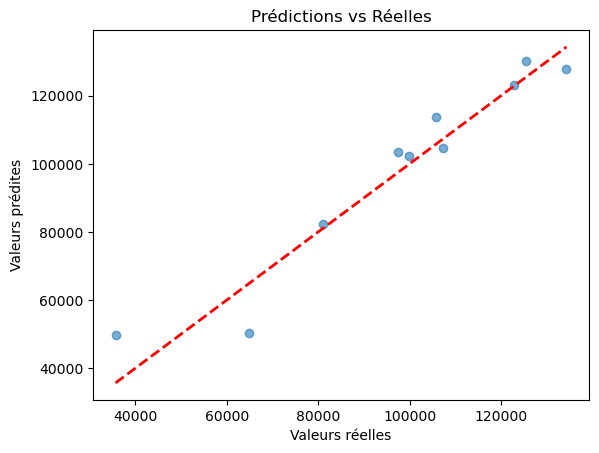

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title('Prédictions vs Réelles')
plt.show()

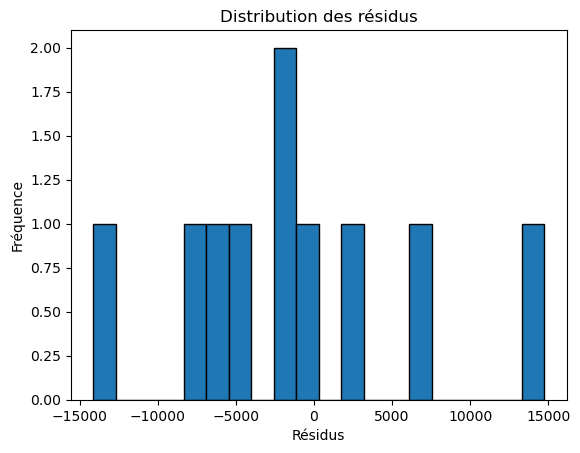

In [ ]:
residuals = y_test - y_pred
plt.hist(residuals, bins=20, edgecolor='k')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Distribution des résidus')
plt.show()

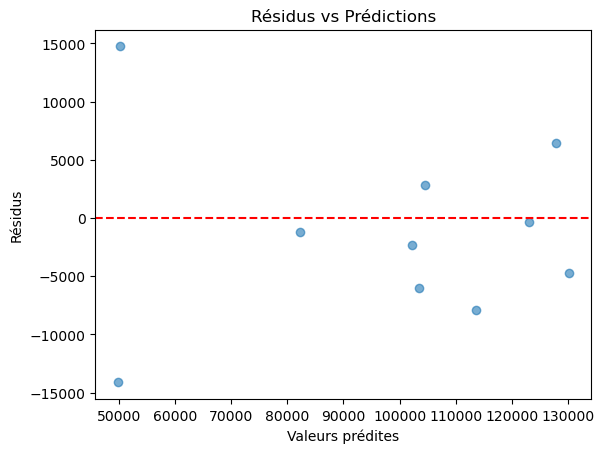

In [ ]:
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')
plt.show()